# Predicción del precio de un coche.


- **Objetivo**

    Crear un modelo predictivo que sea capaz de predecir el valor de un coche de segunda mano en españa.
    Cuidado, va a ser la primera vex que vais a trabajar con un set de datos medianamente grande.

- **Entregable.**

    Un script de python en el que se me soliciten los datos de mi coche y que me devuelva el valor de mi coche.

- **Valorables.**

    Cuanto mas grande sea la precisión y mas facil de usar sea para el usuario(yo).

### Y poco mas... 😄 A por todas y seguid asiiii, que vais genial 🙌🙌🙌
### Animo 🚀🚀

In [1]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from sklearn import metrics

from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

In [2]:
df_1 = pd.read_csv('data/coches-de-segunda-mano-sample.csv')
df_1.head()

,url,company,make,model,version,price,price_financed,fuel,year,kms,...,doors,shift,color,photos,is_professional,dealer,province,country,publish_date,insert_date
0,e158ae0ca53119ca199c28c36b5c2fcd,9881bcdd5a0ad4733037b3fb25e69c3a,SEAT,Toledo,SEAT Toledo 4p.,950,NaN,Diésel,2000.0,227000,...,4,Manual,Verde,5,False,0f4bb8455d27349b8273109b66a847f3,Navarra,Spain,2020-12-18 10:47:13,2021-01-15 00:00:00
1,ff267ebb7e700246f47f84f3db660b4b,9881bcdd5a0ad4733037b3fb25e69c3a,CITROEN,C1,CITROEN C1 PureTech 60KW 82CV Feel 5p.,6200,NaN,Gasolina,2017.0,50071,...,5,Manual,Blanco,6,True,Autos Raymara,Tenerife,Spain,2021-01-02 11:25:40,2021-01-15 00:00:00
2,de4b02db28ea7786c622b969be10c7c7,9881bcdd5a0ad4733037b3fb25e69c3a,FORD,Transit Connect,FORD Transit Connect Van 1.5 TDCi 100cv Ambien...,7851,7024.0,Diésel,2016.0,103000,...,4,Manual,Blanco,10,True,Auto 96,Barcelona,Spain,2020-12-16 10:51:45,2021-01-15 00:00:00
3,0449972a4d07594acf92e9a7dd28b39c,9881bcdd5a0ad4733037b3fb25e69c3a,VOLKSWAGEN,Caravelle,VOLKSWAGEN Caravelle Largo 2.0 TDI 140 Comfort...,19426,NaN,Diésel,2014.0,120000,...,4,Manual,Blanco,9,True,Inniauto,Navarra,Spain,2020-11-25 11:09:14,2021-01-15 00:00:00
4,12c4fa49bd4fdf23f19ecf396d3f02ef,9881bcdd5a0ad4733037b3fb25e69c3a,FORD,Transit,FORD Transit 350 96kW L4 Ambiente Propulsion T...,22850,22800.0,Diésel,2017.0,107000,...,2,Manual,Blanco,4,True,"Autofleet España,s.l",Sevilla,Spain,2021-01-12 20:00:34,2021-01-15 00:00:00


In [3]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   url              50000 non-null  object 
 1   company          50000 non-null  object 
 2   make             49998 non-null  object 
 3   model            49995 non-null  object 
 4   version          50000 non-null  object 
 5   price            50000 non-null  int64  
 6   price_financed   23563 non-null  float64
 7   fuel             49954 non-null  object 
 8   year             49998 non-null  float64
 9   kms              50000 non-null  int64  
 10  power            41472 non-null  float64
 11  doors            50000 non-null  int64  
 12  shift            49889 non-null  object 
 13  color            49406 non-null  object 
 14  photos           50000 non-null  int64  
 15  is_professional  50000 non-null  bool   
 16  dealer           50000 non-null  object 
 17  province    

In [4]:
df_1.describe()

,price,price_financed,year,kms,power,doors,photos
count,50000.000000,23563.000000,49998.000000,5.000000e+04,41472.000000,50000.000000,50000.000000
mean,15166.270260,18480.029283,2012.311032,1.163591e+05,146.396388,4.505380,16.199120
std,16485.669747,13389.800738,6.677760,1.072921e+05,71.283964,0.868001,12.422882
min,300.000000,700.000000,1970.000000,0.000000e+00,29.000000,2.000000,0.000000
25%,5500.000000,10790.000000,2007.000000,3.830000e+04,109.000000,4.000000,7.000000
50%,11750.000000,15500.000000,2015.000000,9.999900e+04,130.000000,5.000000,13.000000
75%,19800.000000,21995.000000,2018.000000,1.749000e+05,163.000000,5.000000,23.000000
max,549900.000000,428999.000000,2021.000000,5.000000e+06,800.000000,5.000000,54.000000


# COLUMNAS QUE EN PRINCIPIO NO ME INTERESAN.
1. LA URL  
2. COMPANY
3. PRICE_FINANCED (Faltan muchos datos)
4. DEALER
5. PHOTOS

In [5]:
df_2 = df_1.drop (['url','company','price_financed','dealer', 'photos'], axis = 1)
df_2

,make,model,version,price,fuel,year,kms,power,doors,shift,color,is_professional,province,country,publish_date,insert_date
0,SEAT,Toledo,SEAT Toledo 4p.,950,Diésel,2000.0,227000,NaN,4,Manual,Verde,False,Navarra,Spain,2020-12-18 10:47:13,2021-01-15 00:00:00
1,CITROEN,C1,CITROEN C1 PureTech 60KW 82CV Feel 5p.,6200,Gasolina,2017.0,50071,82.0,5,Manual,Blanco,True,Tenerife,Spain,2021-01-02 11:25:40,2021-01-15 00:00:00
2,FORD,Transit Connect,FORD Transit Connect Van 1.5 TDCi 100cv Ambien...,7851,Diésel,2016.0,103000,100.0,4,Manual,Blanco,True,Barcelona,Spain,2020-12-16 10:51:45,2021-01-15 00:00:00
3,VOLKSWAGEN,Caravelle,VOLKSWAGEN Caravelle Largo 2.0 TDI 140 Comfort...,19426,Diésel,2014.0,120000,140.0,4,Manual,Blanco,True,Navarra,Spain,2020-11-25 11:09:14,2021-01-15 00:00:00
4,FORD,Transit,FORD Transit 350 96kW L4 Ambiente Propulsion T...,22850,Diésel,2017.0,107000,130.0,2,Manual,Blanco,True,Sevilla,Spain,2021-01-12 20:00:34,2021-01-15 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,HYUNDAI,i30,HYUNDAI i30 1.4 TGDI Tecno Fastback DCT 5p.,18490,Gasolina,2018.0,47000,140.0,5,Automático,Gris / Plata,True,Málaga,Spain,2020-11-24 19:59:52,2021-01-15 00:00:00
49996,RENAULT,Laguna,RENAULT Laguna Coupe Limited 2.0 Energy dCi 15...,14500,Diésel,2015.0,68750,150.0,2,Manual,KNG Gris Casiopea (metalizado),True,Málaga,Spain,2021-01-13 17:02:41,2021-01-15 00:00:00
49997,PEUGEOT,108,PEUGEOT 108 TOP Allure VTi 52kW 72CV 5p.,11000,Gasolina,2019.0,21422,72.0,5,Manual,Gris / Plata,True,Huelva,Spain,2021-01-08 16:47:24,2021-01-15 00:00:00
49998,AUDI,RS4,AUDI RS4 Avant 4.2 FSI 450cv quattro 5p.,47900,Gasolina,2013.0,47900,450.0,5,Automático,Gris / Plata (Antracita),True,Lugo,Spain,2021-01-13 16:22:53,2021-01-15 00:00:00


In [6]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   make             49998 non-null  object 
 1   model            49995 non-null  object 
 2   version          50000 non-null  object 
 3   price            50000 non-null  int64  
 4   fuel             49954 non-null  object 
 5   year             49998 non-null  float64
 6   kms              50000 non-null  int64  
 7   power            41472 non-null  float64
 8   doors            50000 non-null  int64  
 9   shift            49889 non-null  object 
 10  color            49406 non-null  object 
 11  is_professional  50000 non-null  bool   
 12  province         49994 non-null  object 
 13  country          50000 non-null  object 
 14  publish_date     50000 non-null  object 
 15  insert_date      50000 non-null  object 
dtypes: bool(1), float64(2), int64(3), object(10)
memory usage:

In [7]:
filas_con_nulos = df_2[df_2['make'].isna()]
print(filas_con_nulos)  


      make model        version  price       fuel    year  kms  power  doors  \
5659   NaN   D2S   D2S 27kW 3p.  21495  Eléctrico  2021.0    3   37.0      3   
47381  NaN   D2S   D2S 27kW 3p.  21495  Eléctrico  2021.0    6   37.0      3   

            shift  color  is_professional province country  \
5659   Automático  Beige             True   Burgos   Spain   
47381  Automático   Azul             True   Burgos   Spain   

              publish_date          insert_date  
5659   2021-01-13 18:35:29  2021-01-15 00:00:00  
47381  2021-01-13 18:35:29  2021-01-15 00:00:00  


In [8]:
# ELIMINO ESTAS DOS FILAS
df_2 = df_2.drop([5659,47381])
df_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49998 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   make             49998 non-null  object 
 1   model            49993 non-null  object 
 2   version          49998 non-null  object 
 3   price            49998 non-null  int64  
 4   fuel             49952 non-null  object 
 5   year             49996 non-null  float64
 6   kms              49998 non-null  int64  
 7   power            41470 non-null  float64
 8   doors            49998 non-null  int64  
 9   shift            49887 non-null  object 
 10  color            49404 non-null  object 
 11  is_professional  49998 non-null  bool   
 12  province         49992 non-null  object 
 13  country          49998 non-null  object 
 14  publish_date     49998 non-null  object 
 15  insert_date      49998 non-null  object 
dtypes: bool(1), float64(2), int64(3), object(10)
memory usage: 6.2+

In [9]:
#ELIMINO LAS FILAS CON NULOS 
df_3 = df_2.dropna(subset=['model', 'fuel','power','year'])
df_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41465 entries, 1 to 49999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   make             41465 non-null  object 
 1   model            41465 non-null  object 
 2   version          41465 non-null  object 
 3   price            41465 non-null  int64  
 4   fuel             41465 non-null  object 
 5   year             41465 non-null  float64
 6   kms              41465 non-null  int64  
 7   power            41465 non-null  float64
 8   doors            41465 non-null  int64  
 9   shift            41354 non-null  object 
 10  color            41362 non-null  object 
 11  is_professional  41465 non-null  bool   
 12  province         41459 non-null  object 
 13  country          41465 non-null  object 
 14  publish_date     41465 non-null  object 
 15  insert_date      41465 non-null  object 
dtypes: bool(1), float64(2), int64(3), object(10)
memory usage: 5.1+

In [10]:
# TRANSFORMAMOS EL BOOLEANO EN 0 Y 1
df_3.loc[: ,'is_prefessional'] = df_3['is_professional'].astype(int)
df_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41465 entries, 1 to 49999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   make             41465 non-null  object 
 1   model            41465 non-null  object 
 2   version          41465 non-null  object 
 3   price            41465 non-null  int64  
 4   fuel             41465 non-null  object 
 5   year             41465 non-null  float64
 6   kms              41465 non-null  int64  
 7   power            41465 non-null  float64
 8   doors            41465 non-null  int64  
 9   shift            41354 non-null  object 
 10  color            41362 non-null  object 
 11  is_professional  41465 non-null  bool   
 12  province         41459 non-null  object 
 13  country          41465 non-null  object 
 14  publish_date     41465 non-null  object 
 15  insert_date      41465 non-null  object 
 16  is_prefessional  41465 non-null  int64  
dtypes: bool(1), float

C:\Users\amaci\AppData\Local\Temp\ipykernel_14032\2661934381.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_3.loc[: ,'is_prefessional'] = df_3['is_professional'].astype(int)


In [28]:
# GENERAMOS UN CSV NUEVO
df_3.to_csv('data/coches_segunda_mano.csv', index=False)

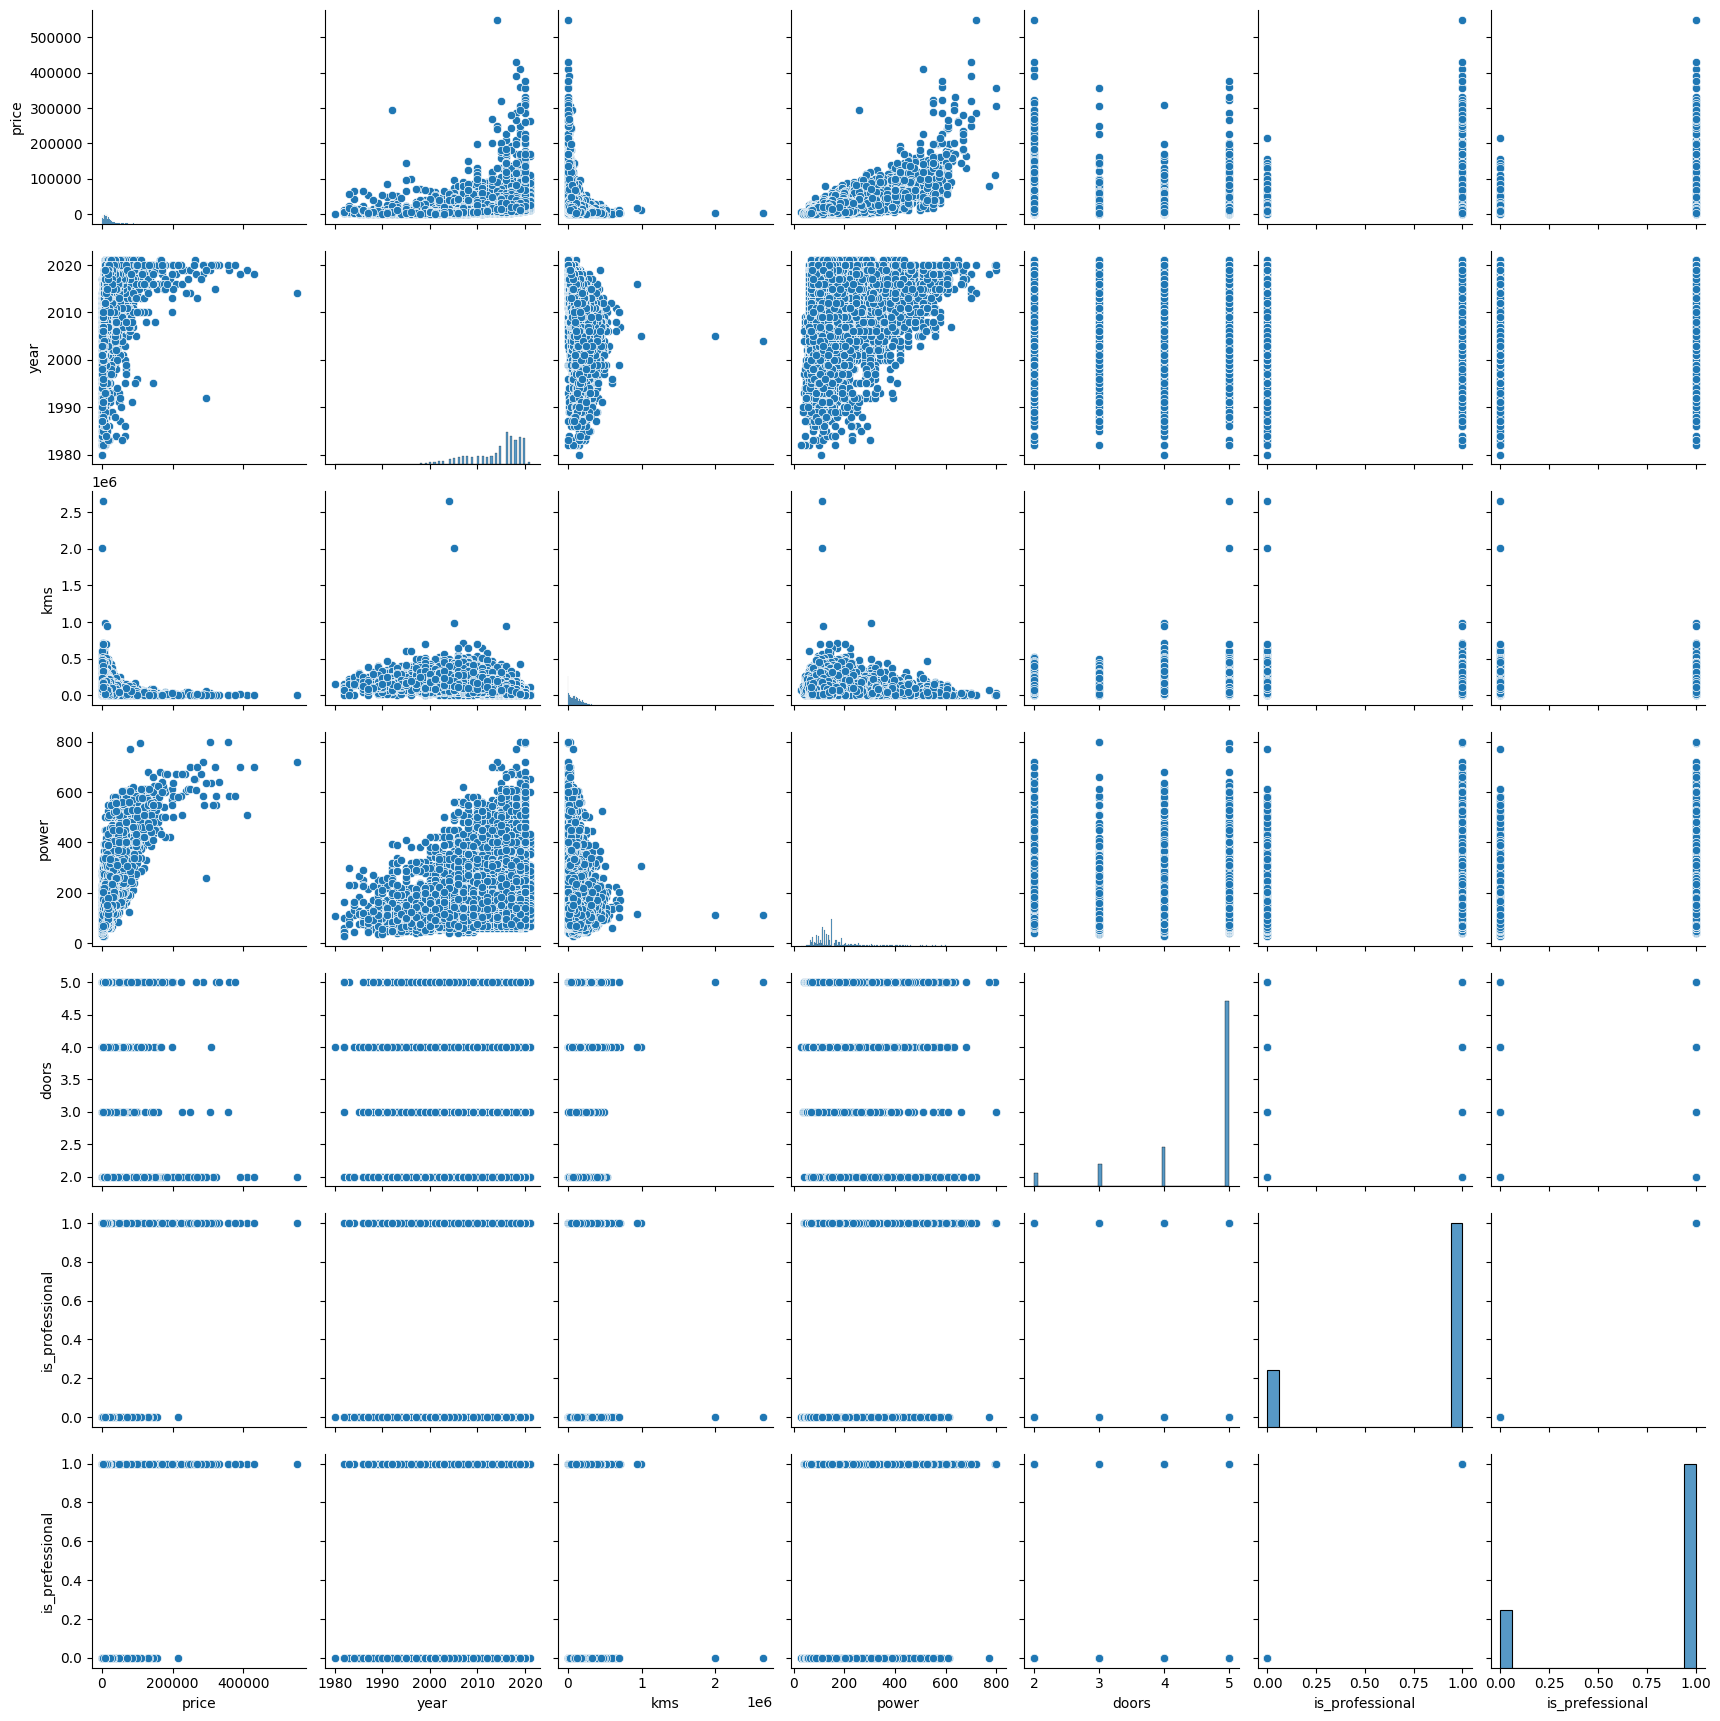

In [29]:
# GRAFICAMOS PARA VER LAS RELACIONES
sns.pairplot(df_3);

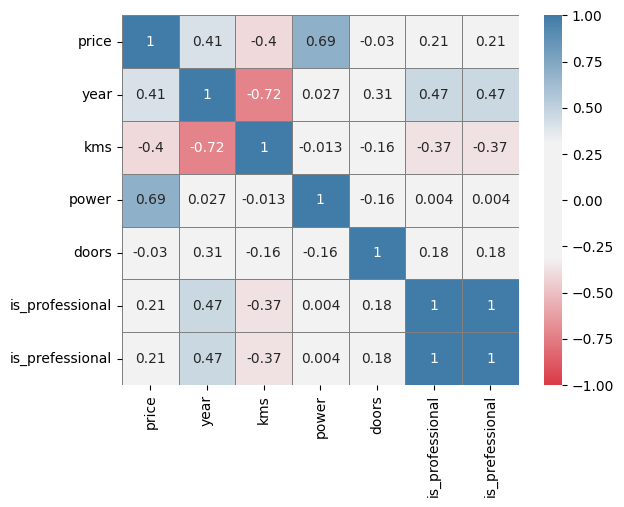

In [12]:
cmap = sns.diverging_palette(10, 240, sep=80, as_cmap=True)
sns.heatmap(df_3.corr(numeric_only=True), annot=True, cmap=cmap, center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor="gray");


In [31]:
# COMENZAMOS CON AÑO - KM - POTENCIA 
X = df_3[['year', 'kms', 'power']]
y = df_3['price'] 

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)

In [33]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [34]:
# COMPROBAMOS
pred = linear_model.predict (X_test)

print('MAE:', metrics.mean_absolute_error(y_test, pred))
print('MAPE', metrics.mean_absolute_percentage_error(y_test, pred))
print('MSE:', metrics.mean_squared_error(y_test, pred)) # BASELINE ERROR
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred))) 
print('score train',linear_model.score(X_train, y_train))
print('score test',linear_model.score(X_test, y_test)) 

MAE: 5048.342530636411
MAPE 0.6130419087792677
MSE: 80767640.56745423
RMSE: 8987.081871634098
score train 0.6548137087646897
score test 0.6870071803582947


In [35]:
# HACEMOS UNA PREDICCION
pred = linear_model
pred_final = linear_model.predict ([[2015, 200000, 120]])
print (pred_final)


[8618.35987944]


c:\Users\amaci\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [36]:
# HAGO UNA REGRESION POLINOMICA 
poly_feats = PolynomialFeatures(degree = 3)
poly_feats.fit(X_train)
X_train_poly = poly_feats.transform(X_train)
X_test_poly = poly_feats.transform(X_test)

In [37]:
pol_reg = LinearRegression()
pol_reg.fit(X_train_poly, y_train)

LinearRegression()

In [38]:
# COMPROBAMOS
pred_1 = pol_reg.predict(X_test_poly)

print('MAE:', metrics.mean_absolute_error(y_test, pred_1))
print('MAPE', metrics.mean_absolute_percentage_error(y_test, pred_1))
print('MSE:', metrics.mean_squared_error(y_test, pred_1))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, pred_1)))
print('score train',pol_reg.score(X_train_poly, y_train))
print('score test',pol_reg.score(X_test_poly, y_test))      

MAE: 4027.1629011584196
MAPE 0.37275001299294086
MSE: 49915330.8668405
RMSE: 7065.078263320265
score train 0.7920042204140669
score test 0.8065668373918491


In [39]:
# HACEMOS UNA PREDICCION 
datos = [[2015, 200000, 120]]  

# CON LA LINEAL
pred = linear_model
pred_final = linear_model.predict (datos)
print (pred_final)

# CON LA POLINOMICA
pred_1 = poly_feats.transform(datos)
pred_1_final = pol_reg.predict(pred_1)
print (pred_1_final)

[8618.35987944]
[9989.02688896]


c:\Users\amaci\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\amaci\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


# LE METEMOS EL USO PROFESIONAL A VER SI MEJORA

In [22]:
X_1 = df_3[['year', 'kms', 'power', 'is_professional']]
y_1 = df_3['price'] 

In [23]:
X_1_train, X_1_test, y_1_train, y_1_test = train_test_split(X_1, y_1, test_size = 0.2, random_state = 10)

In [24]:
linear_model = LinearRegression()
linear_model.fit(X_1_train, y_1_train)

LinearRegression()

In [25]:
# CAMBIA EN LOS ULTIMOS DECIMALES, NO NOS APORTA NADA
pred_1 = linear_model.predict (X_1_test)

print('MAE:', metrics.mean_absolute_error(y_1_test, pred_1))
print('MAPE', metrics.mean_absolute_percentage_error(y_1_test, pred_1))
print('MSE:', metrics.mean_squared_error(y_1_test, pred_1)) # BASELINE ERROR
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_1_test, pred_1))) 
print('score train',linear_model.score(X_1_train, y_1_train))
print('score test',linear_model.score(X_1_test, y_1_test)) 

MAE: 5048.010803062665
MAPE 0.615121613048528
MSE: 80731248.55007382
RMSE: 8985.056958643825
score train 0.6550181212052766
score test 0.6871482076317461


# ME QUEDO CON EL MODELO POLINOMICO DE GRADO TRES Y CON LAS VARIABLES 'year', 'kms', 'power', 'is_professional' (aunque esta última no nos mejore mucho)